# 5. Support vector machine

An SVM separates the two classes with a maximum-margin hyperplane. This is the
linear version, fitted by stochastic gradient descent on the hinge loss; the
kernelised version follows in notebook 06.

In [1]:
import sys
sys.path.append("..")

import numpy as np

from src.data import load_diabetes_data, prepare_diabetes_xy, diabetes_feature_names
from src.classification_metrics import accuracy, precision, f_score
from src.model_selection import make_folds, get_rng, DEFAULT_SEED
from src.plotting import metrics_table
from src.results import record_result

rng = get_rng(DEFAULT_SEED)

from src.preprocessing import standardise, apply_standardisation
from src.svm import append_intercept, sgd, to_binary_labels, cosine_matrix
from src.model_selection import cross_val_svm
from src.plotting import plot_curve, plot_cosine_heatmap

In [2]:
train_df, test_df = load_diabetes_data()
feature_names = diabetes_feature_names(train_df)

# The hinge loss needs labels in {-1, +1}.
X_raw, y = prepare_diabetes_xy(train_df, negative_label=-1)
X_test_raw, y_test = prepare_diabetes_xy(test_df, negative_label=-1)

X, mu, sigma = standardise(X_raw)
X_test = apply_standardisation(X_test_raw, mu, sigma)

# The intercept is appended as the LAST column, because the gradient identifies
# the bias by position (w[-1]) in order to leave it out of the penalty term.
X1 = append_intercept(X)
X_test1 = append_intercept(X_test)

# 0/1 copies for the shared classification metrics.
y_binary, y_test_binary = to_binary_labels(y), to_binary_labels(y_test)

print(f"train {X1.shape}, test {X_test1.shape}")

train (273, 14), test (117, 14)


## Tuning the regularisation strength

`lambda` is swept across ten orders of magnitude. The same design matrix `X1` is
used for both cross-validation and the final fit, so the selected lambda applies
to the model actually reported.

In [3]:
folds = make_folds(len(y), 4, rng=DEFAULT_SEED)

lambda_exponents = np.arange(0, 10)
lambda_values = 10.0 ** lambda_exponents

val_scores = np.array([
    cross_val_svm(y, X1, folds, l, rng=DEFAULT_SEED, max_iterations=1025)
    for l in lambda_values
])

for e, s in zip(lambda_exponents, val_scores):
    print(f"lambda 1e{e}: CV accuracy {s:.4f}")

optimal_lambda = lambda_values[int(np.argmax(val_scores))]
print(f"\noptimal lambda: {optimal_lambda:g}")

lambda 1e0: CV accuracy 0.8463
lambda 1e1: CV accuracy 0.9010
lambda 1e2: CV accuracy 0.9084
lambda 1e3: CV accuracy 0.9121
lambda 1e4: CV accuracy 0.9122
lambda 1e5: CV accuracy 0.9121
lambda 1e6: CV accuracy 0.8865
lambda 1e7: CV accuracy 0.8717
lambda 1e8: CV accuracy 0.8721
lambda 1e9: CV accuracy 0.8793

optimal lambda: 10000


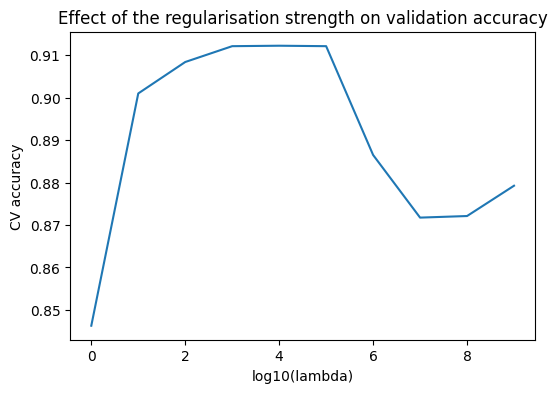

In [4]:
plot_curve(lambda_exponents, val_scores, "log10(lambda)", "CV accuracy",
           "Effect of the regularisation strength on validation accuracy")

## How the separating hyperplane turns with lambda

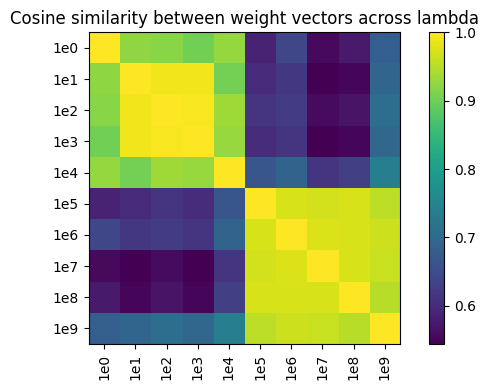

In [5]:
weight_vectors = [
    sgd(X1, y, l, rng=DEFAULT_SEED, max_iterations=1025) for l in lambda_values
]

plot_cosine_heatmap(
    cosine_matrix(weight_vectors),
    tick_labels=[f"1e{e}" for e in lambda_exponents],
    title="Cosine similarity between weight vectors across lambda",
)

A larger lambda penalises misclassification more heavily, so the algorithm
prioritises a smaller margin that separates the classes with fewer errors. A
smaller lambda penalises misclassification less, favouring a wider margin even
where that admits more errors. Tuning it is therefore a bias-variance trade-off.

The heatmap reads as a map of how far the hyperplane rotates: weight vectors
fitted under similar lambdas point in similar directions and score close to 1,
while those from opposite ends of the range approach orthogonality and score near
0. The diagonal is 1 throughout, since every vector is perfectly aligned with
itself.

A low-hardness SVM tolerates noise and outliers and yields a simpler boundary
that often generalises better, at the risk of underfitting. A high-hardness SVM
tolerates them less and produces a more complex boundary prone to overfitting,
though it can perform well where the data really is highly separable.

## Performance at the selected lambda

fitted 14 weights (the last is the intercept: -1.8000)


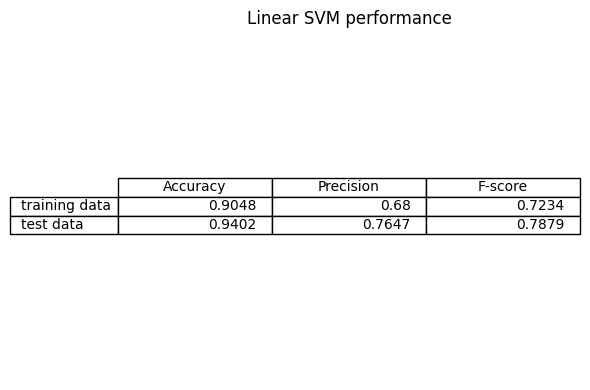

,model,split,mse,r_squared,accuracy,precision,f_score
0,Elastic net,test,1.984829,0.908297,NaN,NaN,NaN
1,Elastic net,train,1.875560,0.917734,NaN,NaN,NaN
2,Lasso,test,1.984805,0.908298,NaN,NaN,NaN
3,Lasso,train,1.875886,0.917720,NaN,NaN,NaN
4,Least squares,test,1.984390,0.908317,NaN,NaN,NaN
5,Least squares,train,1.875557,0.917734,NaN,NaN,NaN
6,Linear SVM,test,NaN,NaN,0.940171,0.764706,0.787879
7,Linear SVM,train,NaN,NaN,0.904762,0.680000,0.723404
8,Random forest,test,NaN,NaN,0.888889,0.600000,0.580645
9,Random forest,train,NaN,NaN,0.970696,0.973684,0.902439


In [6]:
w = sgd(X1, y, optimal_lambda, rng=rng, max_iterations=2049)
print(f"fitted {len(w)} weights (the last is the intercept: {w[-1]:.4f})")

y_pred = to_binary_labels(np.sign(X1 @ w))
y_pred_test = to_binary_labels(np.sign(X_test1 @ w))

svm_train = [accuracy(y_binary, y_pred), precision(y_binary, y_pred),
             f_score(y_binary, y_pred)]
svm_test = [accuracy(y_test_binary, y_pred_test), precision(y_test_binary, y_pred_test),
            f_score(y_test_binary, y_pred_test)]

metrics_table([svm_train, svm_test],
              columns=("Accuracy", "Precision", "F-score"),
              row_labels=("training data", "test data"),
              title="Linear SVM performance")

record_result("Linear SVM", "train", accuracy=svm_train[0], precision=svm_train[1], f_score=svm_train[2])
record_result("Linear SVM", "test", accuracy=svm_test[0], precision=svm_test[1], f_score=svm_test[2])

**Next:** [06_kernel_svm.ipynb](06_kernel_svm.ipynb)